# AutoEIT — Transcription Quality: resegmented (v2 window, 4s merge-gap) (whole dataset)

`data/segmented/v2/` is an experimental re-segmentation (`src/preprocessing/resegment_window.py`,
see `data/segmented/v2/README.md` and `notebooks/segmentation/analyze_resegmented_window.ipynb`): windowed to
just the Spanish target-sentence region, with a 4s VAD merge-gap threshold (vs. 2.5s for the
original segmentation). It raises the "hit" (exactly 30 items) rate from 45.7% to 55.4% (102 of
184 valid recordings, vs. 84 previously).

All twelve ASR models now evaluated against this resegmentation
(`src/transcription/transcribe_resegmented_*.py`), merged with the human transcriptions via
`src/postprocessing/build_postprocessed_csv_resegmented.py`, the same rank-based
item&lt;-&gt;Sentence alignment and WER/MER/CER scoring (via `jiwer`, after lowercasing/punctuation
stripping) as `src/postprocessing/build_postprocessed_csv.py`:

- **whisper** — faster-whisper large-v3, Spanish forced (the original baseline).
- **parakeet** — NVIDIA Parakeet-TDT-0.6B-v3.
- **wav2vec2** — jonatasgrosman/wav2vec2-large-xlsr-53-spanish, CTC.
- **crisperwhisper** — nyrahealth/faster_CrisperWhisper, a verbatim-transcription Whisper
  fine-tune; hit-recordings only (see `notebooks/model_comparison/analyze_crisperwhisper_transcription_quality.ipynb`
  for the dedicated writeup — it scores far worse than the other five here).
- **fastconformer** — nvidia/stt_es_fastconformer_hybrid_large_pc, decoded via its CTC head (see
  `notebooks/model_comparison/analyze_fastconformer_transcription_quality.ipynb`).
- **canary** — nvidia/canary-1b, a FastConformer-Transformer encoder-decoder decoded via its
  attention-based (AED) head.
- **mms** — facebook/mms-1b-all, CTC decoded via ~1,100 per-language adapter weights rather than
  wav2vec2-xlsr-53's dedicated Spanish fine-tune; hit-recordings only (see
  `notebooks/model_comparison/analyze_mms_transcription_quality.ipynb`).
- **seamlessm4t** — facebook/seamless-m4t-v2-large, an attention-based speech-to-text-translation
  model run with source and target language both pinned to Spanish; hit-recordings only (see
  `notebooks/model_comparison/analyze_seamlessm4t_transcription_quality.ipynb`).
- **canary_v2** — nvidia/canary-1b-v2, a 2026-06-23 follow-up checkpoint to canary-1b with the
  same architecture, expanded to 25 languages, and real word-level timestamps (unlike v1's
  whole-clip fallback); run on every recording (hit and miss), same as v1 (see
  `notebooks/model_comparison/analyze_canary_v2_transcription_quality.ipynb`).
- **assemblyai** — AssemblyAI Universal-2, pinned per advisor instruction to evaluate the actual
  `autoeit.org` production model; hit-recordings only (billed API) (see
  `notebooks/model_comparison/analyze_assemblyai_transcription_quality.ipynb`).
- **speechmatics** — Speechmatics Enhanced (batch), `remove_disfluencies=False`; hit-recordings only
  (billed API) (see `notebooks/model_comparison/analyze_speechmatics_transcription_quality.ipynb`).
- **assemblyai_v3** — AssemblyAI Universal-3.5 Pro paired with Speech-to-Text Prompting (an explicit
  disfluency-preservation instruction), a follow-up to `assemblyai`'s plain Universal-2 run;
  hit-recordings only (billed API) (see
  `notebooks/model_comparison/analyze_assemblyai_v3_transcription_quality.ipynb`).

An earlier version of this notebook split the 102 hit recordings into train/val/test, treating this
like a model-selection problem that needed a held-out check. There's no actual tuning process here
(no thresholds or hyperparameters being searched) — it's a one-shot comparison of fixed,
already-trained ASR models — so the split only threw away recordings without buying anything. This
version scores all 102 hit recordings at once (`data/resegmented_hit_recordings.txt`).

## Metrics: WER, MER, and CER

- **WER (Word Error Rate)** = (S + D + I) / N, where N is the number of words in the reference.
  Unbounded above 1.0 when there are many insertions relative to the reference.
- **MER (Match Error Rate)** = (S + D + I) / (S + D + C + I). Same edit counts as WER, but always in
  [0, 1] — doesn't blow up the way WER can on insertion-heavy output.
- **CER (Character Error Rate)** — the same idea as WER but over characters, more forgiving of
  near-miss spelling/inflection errors and less sensitive to tokenization.

All three are computed after lowercasing and stripping punctuation, against each human rater
separately.


## Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
POSTPROCESSED_ROOT = Path("../../data/postprocessed/resegmented")
VERSIONS = ["version_a", "version_b"]
ASR_SOURCES = ["whisper", "parakeet", "wav2vec2", "crisperwhisper", "fastconformer", "canary", "mms", "seamlessm4t", "canary_v2", "assemblyai", "speechmatics", "assemblyai_v3"]
RATERS = ["rater1", "rater2"]
METRICS = ["wer", "mer", "cer"]

hit_recordings = set(Path("../../data/resegmented_hit_recordings.txt").read_text(encoding="utf-8").split())
print(f"{len(hit_recordings)} hit recordings")


102 hit recordings


## Load per-item scores

One tidy row per (recording, sentence, ASR source, rater), across all hit recordings.

In [3]:
def load_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            for source in ASR_SOURCES:
                for rater in RATERS:
                    cols = [f"{source}_{m}_{rater}" for m in METRICS]
                    if cols[0] not in df.columns:
                        continue
                    sub = df[["sentence_number", *cols]].dropna()
                    for _, row in sub.iterrows():
                        records.append({
                            "version": version,
                            "recording": recording_dir.name,
                            "sentence_number": row["sentence_number"],
                            "source": source,
                            "rater": rater,
                            "wer": row[cols[0]],
                            "mer": row[cols[1]],
                            "cer": row[cols[2]],
                        })
    return pd.DataFrame(records)


scores = load_scores(hit_recordings)
n_rec = scores["recording"].nunique()
print(f"{len(scores)} scored items, {n_rec} recordings")

70548 scored items, 98 recordings


## Human floor

For context, the inter-rater agreement floor (rater1 vs. rater2, same scoring, see
`analyze_interrater_agreement.ipynb` for the full writeup) over this same 102-recording set, shown
alongside the ASR systems below.

In [4]:
def load_human_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            if "human_wer" not in df.columns:
                continue
            sub = df[["sentence_number", "human_wer", "human_mer", "human_cer"]].dropna()
            for _, row in sub.iterrows():
                records.append({
                    "version": version,
                    "recording": recording_dir.name,
                    "sentence_number": row["sentence_number"],
                    "source": "human",
                    "rater": "rater1_vs_rater2",
                    "wer": row["human_wer"],
                    "mer": row["human_mer"],
                    "cer": row["human_cer"],
                })
    return pd.DataFrame(records)


human_scores = load_human_scores(hit_recordings)
scores_with_human = pd.concat([scores, human_scores], ignore_index=True)
print(f"human floor: {len(human_scores)} scored sentences")

human floor: 2940 scored sentences


In [5]:
source_colors = {
    "whisper": "#4C72B0",
    "parakeet": "#DD8452",
    "wav2vec2": "#55A868",
    "crisperwhisper": "#C44E52",
    "fastconformer": "#8172B2",
    "canary": "#937860",
    "mms": "#64B5CD",
    "seamlessm4t": "#CCB974",
    "canary_v2": "#4C4C4C",
    "assemblyai": "#DA8BC3",
    "speechmatics": "#1F9E89",
    "assemblyai_v3": "#F2A104",
    "human": "#777777",
}
DISPLAY_SOURCES = ASR_SOURCES + ["human"]


def summarize(scores: pd.DataFrame, order: list[str] = ASR_SOURCES) -> pd.DataFrame:
    mean_tbl = scores.groupby("source")[METRICS].mean().round(4).reindex(order)
    median_tbl = scores.groupby("source")[METRICS].median().round(4).reindex(order)
    pct_perfect = scores.groupby("source")["wer"].apply(lambda x: (x == 0).mean()).round(3).reindex(order)
    out = mean_tbl.add_suffix("_mean").join(median_tbl.add_suffix("_median"))
    out["wer_pct_perfect"] = pct_perfect
    return out


def plot_metrics(scores: pd.DataFrame, title: str, save_path: str, order: list[str] = ASR_SOURCES) -> None:
    summary = scores.groupby("source")[METRICS].mean().reindex(order)
    x = np.arange(len(order))
    width = 0.25

    # Figure width scales with the number of bars so labels stay readable as more sources are
    # added (fixed at 12in when this only had to fit ~10 sources) -- and long labels get rotated
    # once there are enough of them to start overlapping.
    fig_width = max(12, len(order) * 1.15)
    fig, ax = plt.subplots(figsize=(fig_width, 5))
    for i, metric in enumerate(METRICS):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, summary[metric], width, label=metric.upper())
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    rotation = 20 if len(order) > 8 else 0
    ax.set_xticklabels(order, rotation=rotation, ha="right" if rotation else "center")
    ax.set_ylabel("Mean error rate")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


## Whole dataset (n=102, both raters), ASR vs. human floor

In [6]:
summarize(scores_with_human, order=DISPLAY_SOURCES)

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
parakeet,0.2805,0.2596,0.1558,0.1429,0.1429,0.0513,0.329
wav2vec2,0.3230,0.3003,0.1489,0.2500,0.2500,0.0769,0.207
crisperwhisper,0.6897,0.6380,0.3761,0.7500,0.7059,0.2857,0.020
fastconformer,0.2506,0.2331,0.1319,0.1667,0.1667,0.0606,0.297
canary,0.2476,0.2129,0.1341,0.1429,0.1250,0.0435,0.368
mms,0.3987,0.3815,0.1893,0.2857,0.2857,0.1000,0.205
seamlessm4t,0.3770,0.3186,0.2186,0.2222,0.2000,0.0930,0.270
canary_v2,0.3014,0.2593,0.1809,0.1667,0.1667,0.0638,0.327


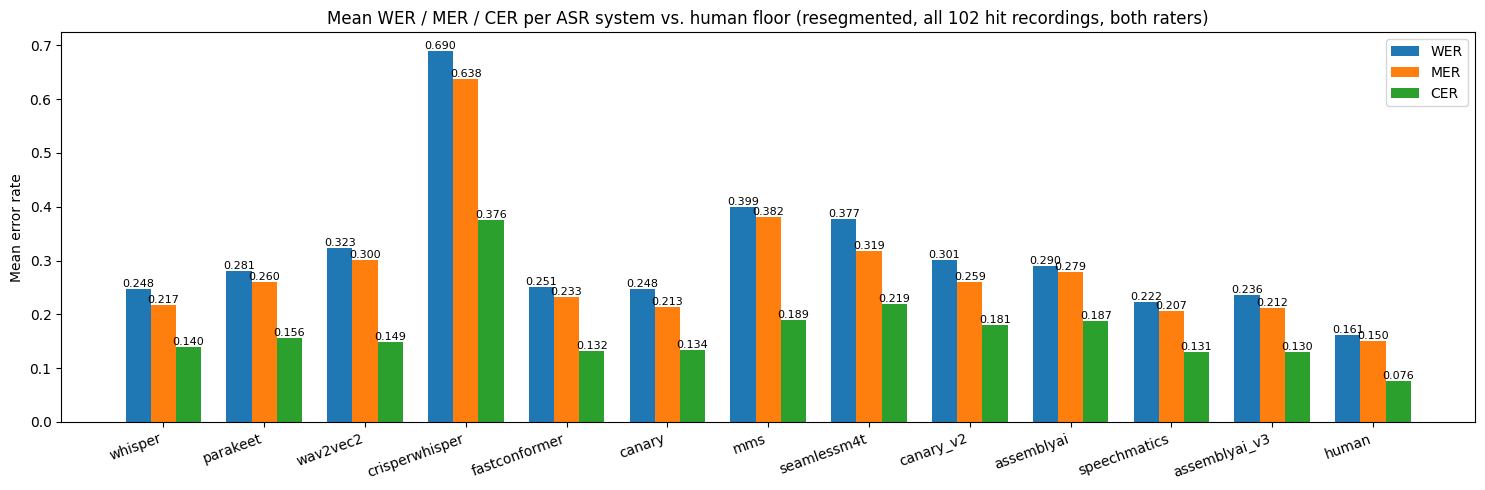

In [7]:
plot_metrics(scores_with_human, "Mean WER / MER / CER per ASR system vs. human floor (resegmented, all 102 hit recordings, both raters)",
             "../plots/resegmented_transcription_quality_metrics.png", order=DISPLAY_SOURCES)


## Full summary table as a chart

The `summarize()` table above (mean WER / MER / CER, plus the % of items scored word-perfect)
side by side per system, as one figure instead of a table.

In [8]:
def plot_full_summary(summary: pd.DataFrame, title: str, save_path: str, figsize: tuple[float, float] = (13, 5.5)) -> None:
    order = summary.index.tolist()
    metrics = ["wer_mean", "mer_mean", "cer_mean", "wer_pct_perfect"]
    labels = ["WER", "MER", "CER", "% perfect (WER=0)"]
    colors = ["#2a78d6", "#008300", "#e87ba4", "#eda100"]  # validated categorical slots 1-4

    x = np.arange(len(order))
    width = 0.2

    fig, ax = plt.subplots(figsize=figsize)
    for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
        offset = (i - 1.5) * width
        bars = ax.bar(x + offset, summary[metric], width, label=label, color=color)
        for b in bars:
            h = b.get_height()
            text = f"{h:.0%}" if metric == "wer_pct_perfect" else f"{h:.3f}"
            ax.text(b.get_x() + b.get_width() / 2, h, text, ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Value")
    ax.set_title(title, pad=14)
    ax.legend(ncols=4, loc="upper center", bbox_to_anchor=(0.5, -0.08), frameon=False)
    fig.text(
        0.5, -0.02, "WER / MER / CER: lower is better    |    % perfect: higher is better",
        ha="center", fontsize=9, color="#52514e",
    )
    fig.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


## Best models only: speechmatics and assemblyai_v3 vs. human floor

Same chart, restricted to the two strongest ASR systems (`speechmatics`, `assemblyai_v3` — the
two commercial-API systems that overtook the long-standing `canary`/`whisper` tie, see
`docs/asr_model_comparison_analysis.md` §1.2) plus the human inter-rater floor, dropping the other
ten systems for a focused comparison.


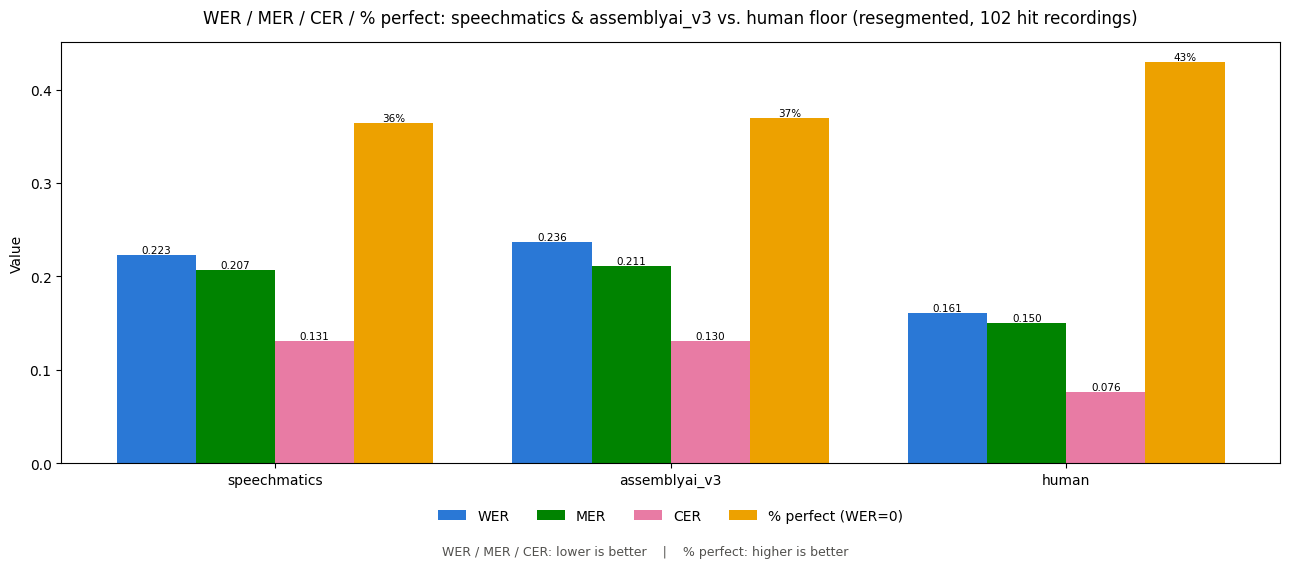

In [9]:
BEST_SOURCES = ["speechmatics", "assemblyai_v3", "human"]

best_summary_table = summarize(scores_with_human, order=BEST_SOURCES)
plot_full_summary(
    best_summary_table,
    "WER / MER / CER / % perfect: speechmatics & assemblyai_v3 vs. human floor (resegmented, 102 hit recordings)",
    "../plots/resegmented_best_vs_human.png",
)


## Five-model comparison: human floor, canary, whisper, speechmatics, assemblyai_v3

A broader version of the "best models only" chart above: the human inter-rater floor alongside the
two long-standing open-source leaders (`canary`, `whisper`, tied at WER 0.248) and the two
commercial systems that overtook them (`speechmatics`, `assemblyai_v3` — see §1.2 of
`docs/asr_model_comparison_analysis.md`), all five side by side.


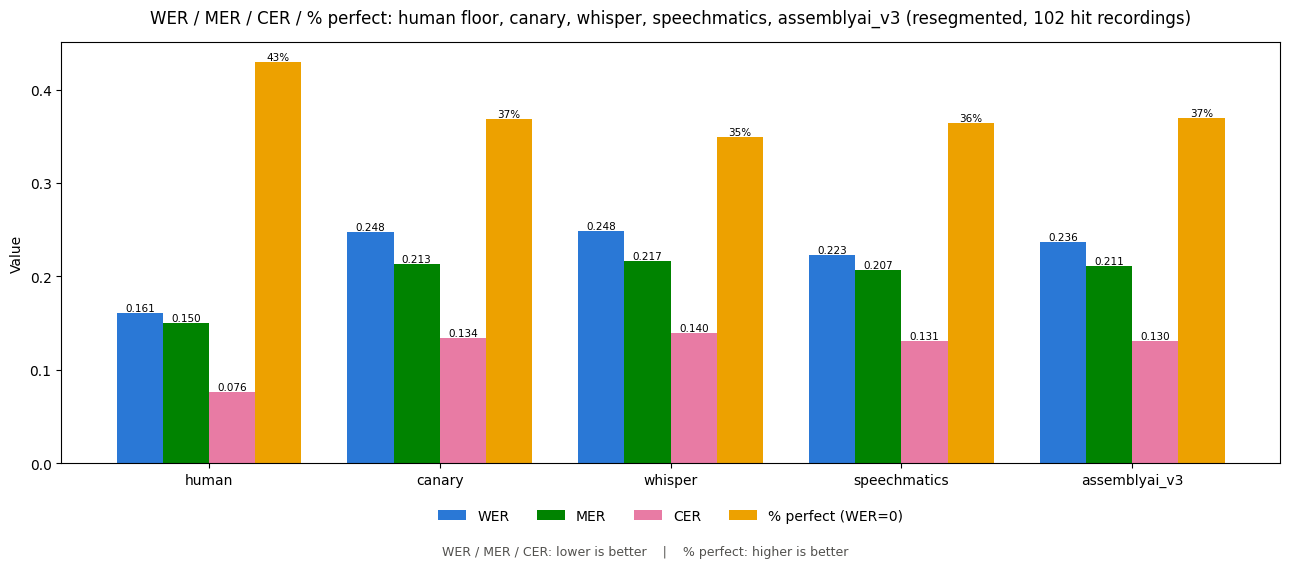

In [10]:
FIVE_SOURCES = ["human", "canary", "whisper", "speechmatics", "assemblyai_v3"]

five_model_summary = summarize(scores_with_human, order=FIVE_SOURCES)
plot_full_summary(
    five_model_summary,
    "WER / MER / CER / % perfect: human floor, canary, whisper, speechmatics, assemblyai_v3 (resegmented, 102 hit recordings)",
    "../plots/resegmented_five_model_comparison.png",
)


## Each ASR system vs. human floor, individually

The combined charts above put every system side by side, which makes the absolute gap to the
human floor hard to read once there are this many bars. One plot per system, isolating it against
just the human floor, for a cleaner one-on-one comparison.

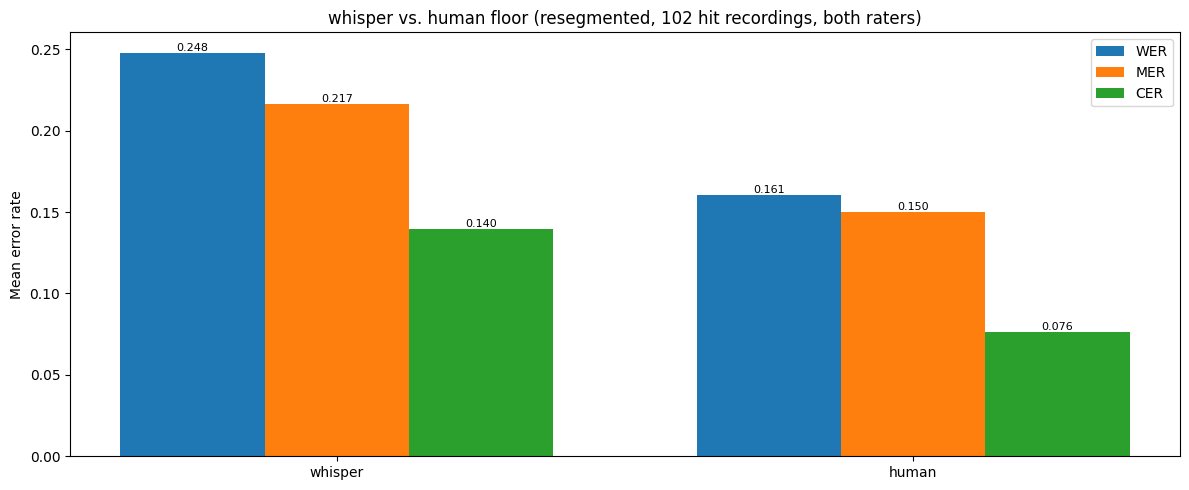

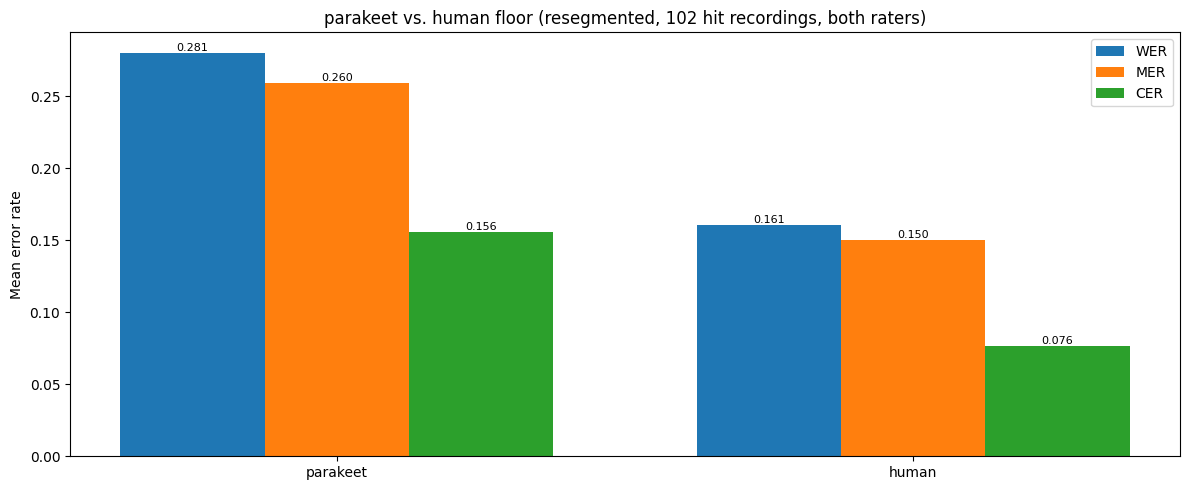

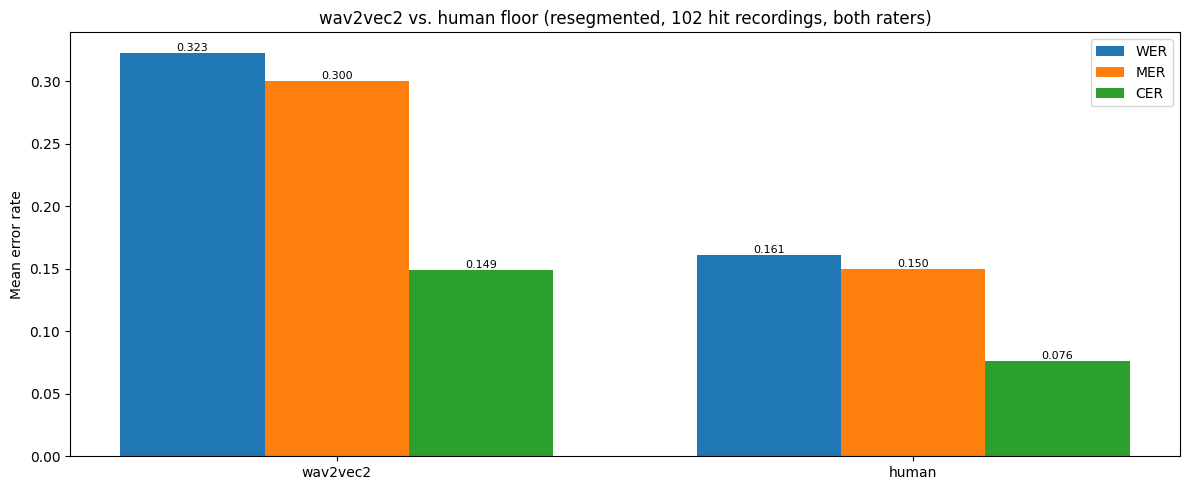

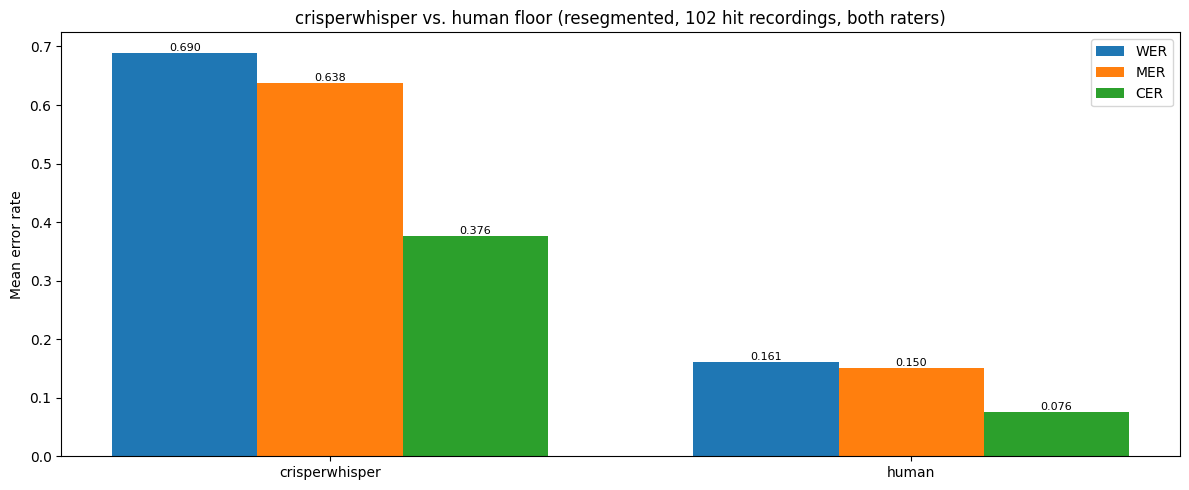

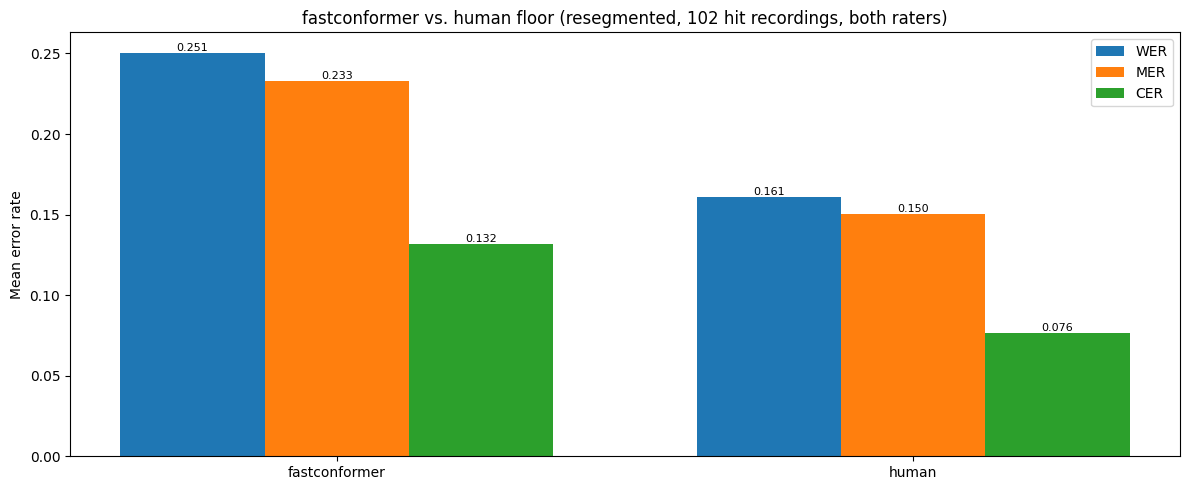

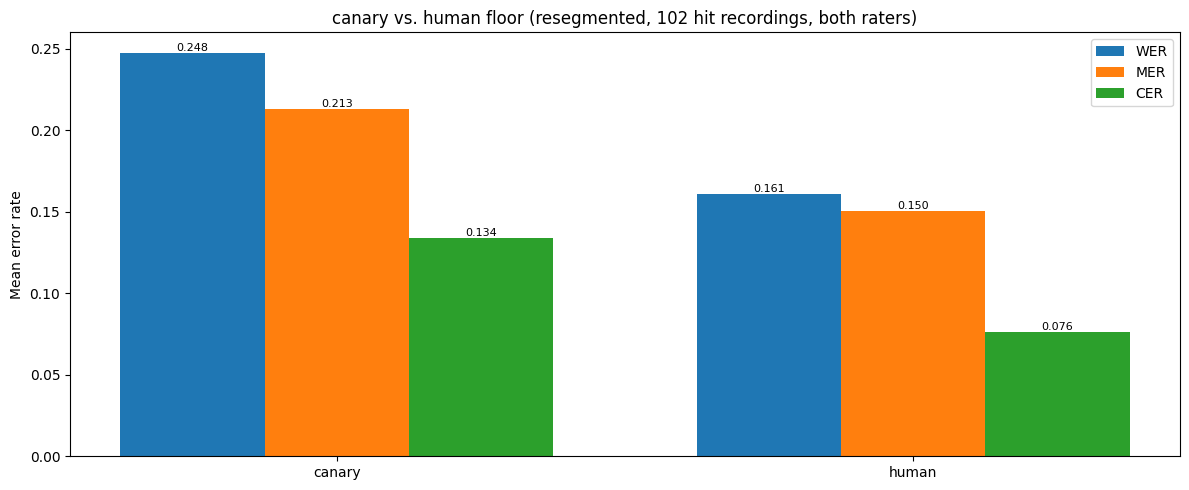

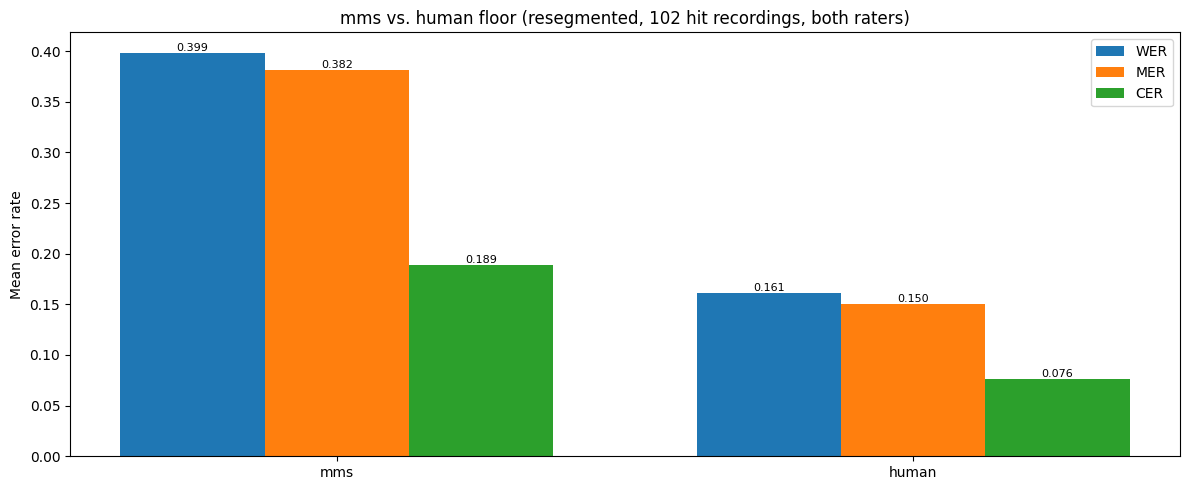

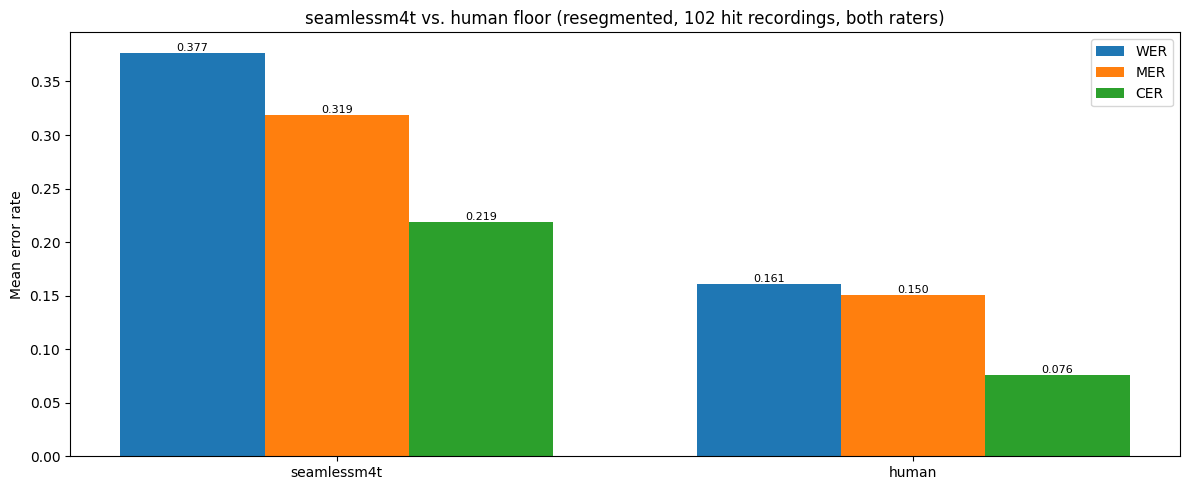

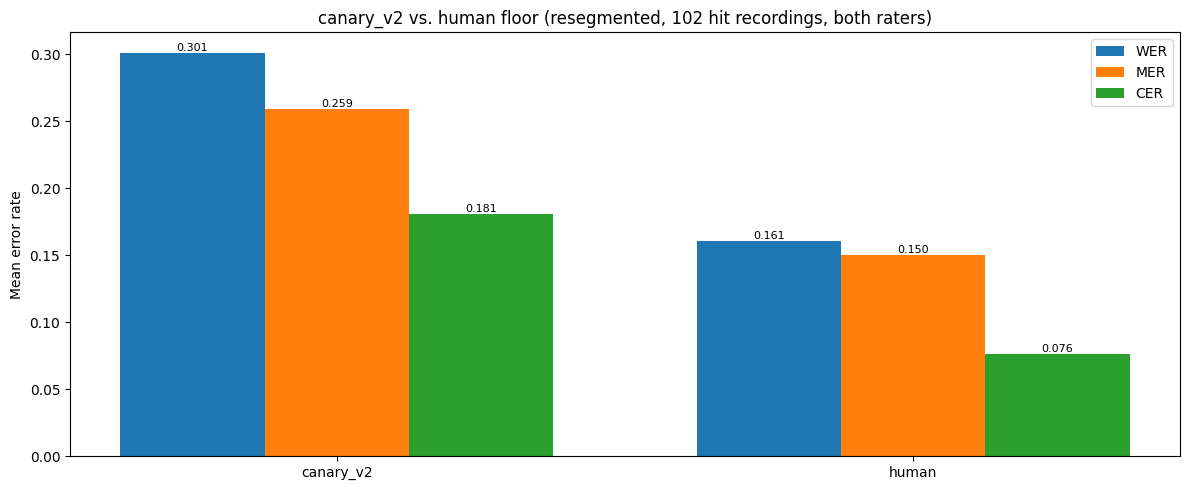

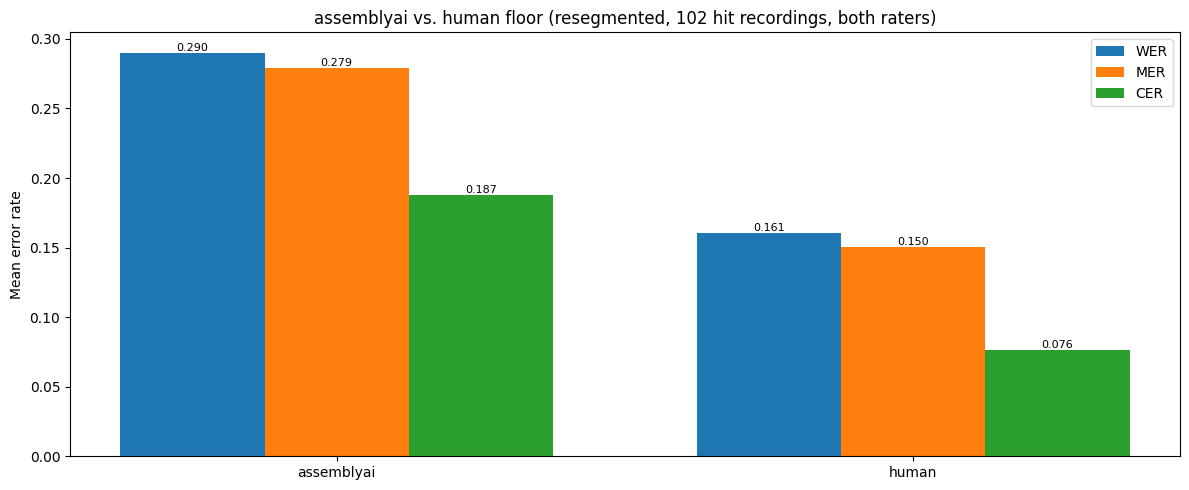

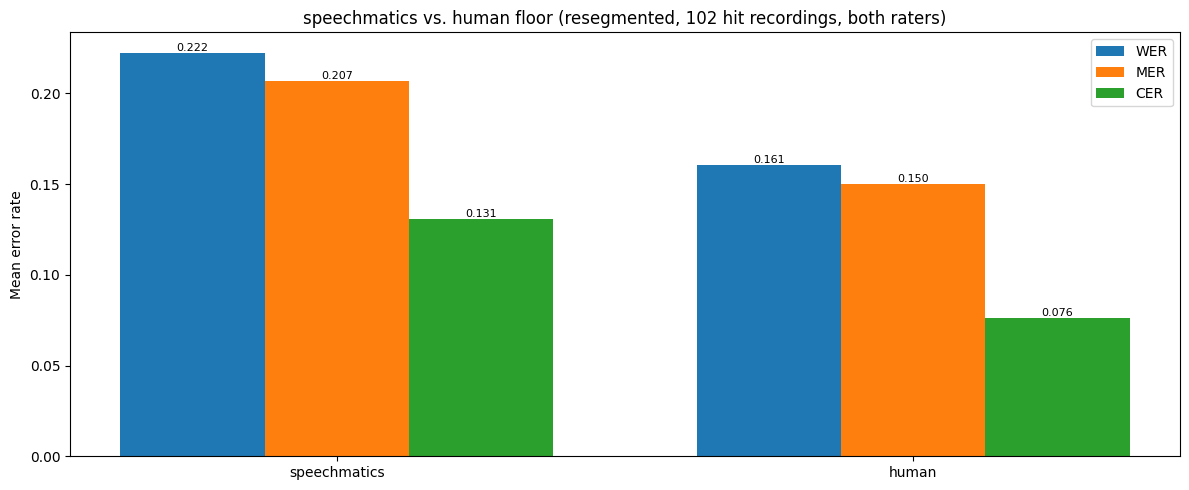

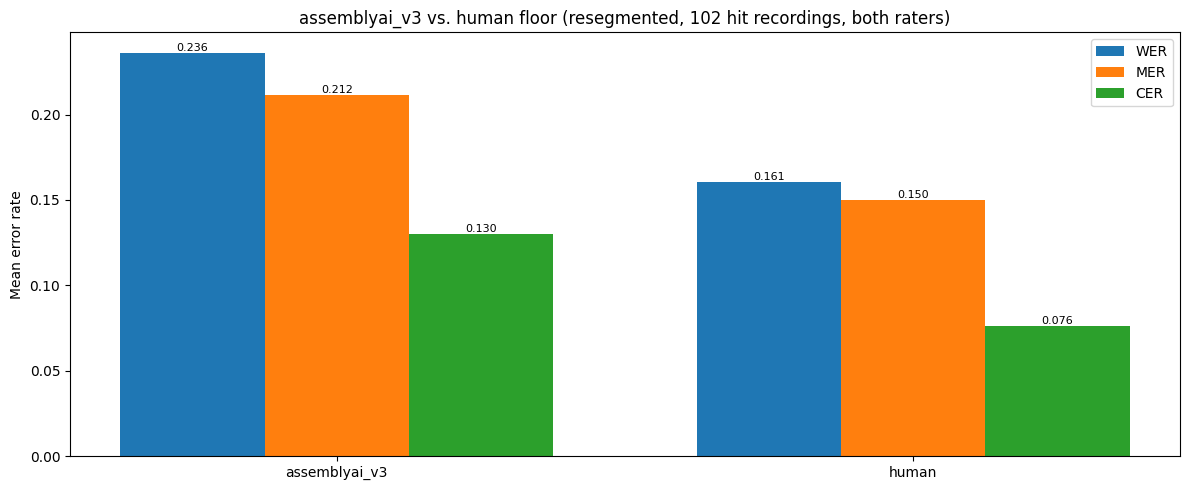

In [11]:
for source in ASR_SOURCES:
    pair = scores_with_human[scores_with_human["source"].isin([source, "human"])]
    plot_metrics(
        pair,
        f"{source} vs. human floor (resegmented, 102 hit recordings, both raters)",
        f"../plots/{source}_vs_human_metrics.png",
        order=[source, "human"],
    )


## All sources vs. the stimulus (scripted target sentence)

Every comparison above scores a source against a **human rater's transcription of what was
actually said**. This section instead scores all nine ASR systems *and* each human rater's own
transcription directly against the **`stimulus`** column — the scripted Spanish sentence the
learner was asked to repeat (with the trailing `(N)` syllable-count annotation stripped, e.g.
`"Quiero cortarme el pelo (7)"` -> `"Quiero cortarme el pelo"`).

This measures something different from the rest of the notebook: distance from the *intended*
sentence, not distance from the *spoken* one. Two things push a source's stimulus-WER up that
don't affect its human-floor WER at all:

- **ASR error**, same as before.
- **The learner's own deviation from the script** (self-corrections, mispronunciations that read as
  a different word, dropped/added words, disfluencies) — something no ASR improvement can fix,
  since it's not a transcription error at all.

That's why even the **human raters' own transcriptions** are scored here (`human_rater1`,
`human_rater2`): they set the floor for how far a *perfect* transcription still ends up from the
stimulus, purely from learner deviation. Any ASR system's gap above that human floor is the part
attributable to actual transcription error, on this metric.

In [12]:
import re
import jiwer

STIMULUS_SOURCES = ASR_SOURCES + ["human_rater1", "human_rater2"]


def strip_stimulus_suffix(stimulus) -> str:
    if not stimulus:
        return ""
    return re.sub(r"\s*\(\d+\)\s*$", "", str(stimulus)).strip()


def normalize_text(text) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    return re.sub(r"\s+", " ", text).strip()


def compute_wer_mer_cer(reference, hypothesis) -> tuple[float | None, float | None, float | None]:
    ref_norm = normalize_text(reference)
    if not ref_norm:
        return None, None, None
    hyp_norm = normalize_text(hypothesis)
    result = jiwer.process_words(ref_norm, hyp_norm)
    cer = jiwer.cer(ref_norm, hyp_norm)
    return round(result.wer, 4), round(result.mer, 4), round(cer, 4)


def load_stimulus_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            if "stimulus" not in df.columns:
                continue
            for _, row in df.iterrows():
                stimulus = strip_stimulus_suffix(row.get("stimulus"))
                if not stimulus:
                    continue
                for source in STIMULUS_SOURCES:
                    hyp = row.get(f"{source}_text")
                    wer, mer, cer = compute_wer_mer_cer(stimulus, hyp)
                    if wer is None:
                        continue
                    records.append({
                        "version": version,
                        "recording": recording_dir.name,
                        "sentence_number": row["sentence_number"],
                        "source": source,
                        "wer": wer,
                        "mer": mer,
                        "cer": cer,
                    })
    return pd.DataFrame(records)


stimulus_scores = load_stimulus_scores(hit_recordings)
print(f"{len(stimulus_scores)} scored items vs. stimulus, {stimulus_scores['recording'].nunique()} recordings")


42840 scored items vs. stimulus, 102 recordings


In [13]:
stimulus_summary = summarize(stimulus_scores, order=STIMULUS_SOURCES)
stimulus_summary_display = stimulus_summary.rename(
    index={"human_rater1": "human (r1)", "human_rater2": "human (r2)"}
)
stimulus_summary_display


,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.5138,0.3404,0.5072,0.2857,0.2727,0.1522,0.263
parakeet,0.5532,0.3874,0.5310,0.3333,0.3333,0.1739,0.223
wav2vec2,0.6154,0.4413,0.5451,0.4444,0.4286,0.2174,0.122
crisperwhisper,0.8937,0.7133,0.7291,0.8571,0.8000,0.4222,0.013
fastconformer,0.5485,0.3792,0.5168,0.3333,0.3333,0.1837,0.185
canary,0.5363,0.3578,0.5189,0.3000,0.3000,0.1739,0.238
mms,0.6555,0.4901,0.5549,0.4772,0.4545,0.2286,0.129
seamlessm4t,0.6146,0.4161,0.5706,0.3750,0.3636,0.2222,0.222
canary_v2,0.5509,0.3720,0.5389,0.3333,0.3000,0.1786,0.249


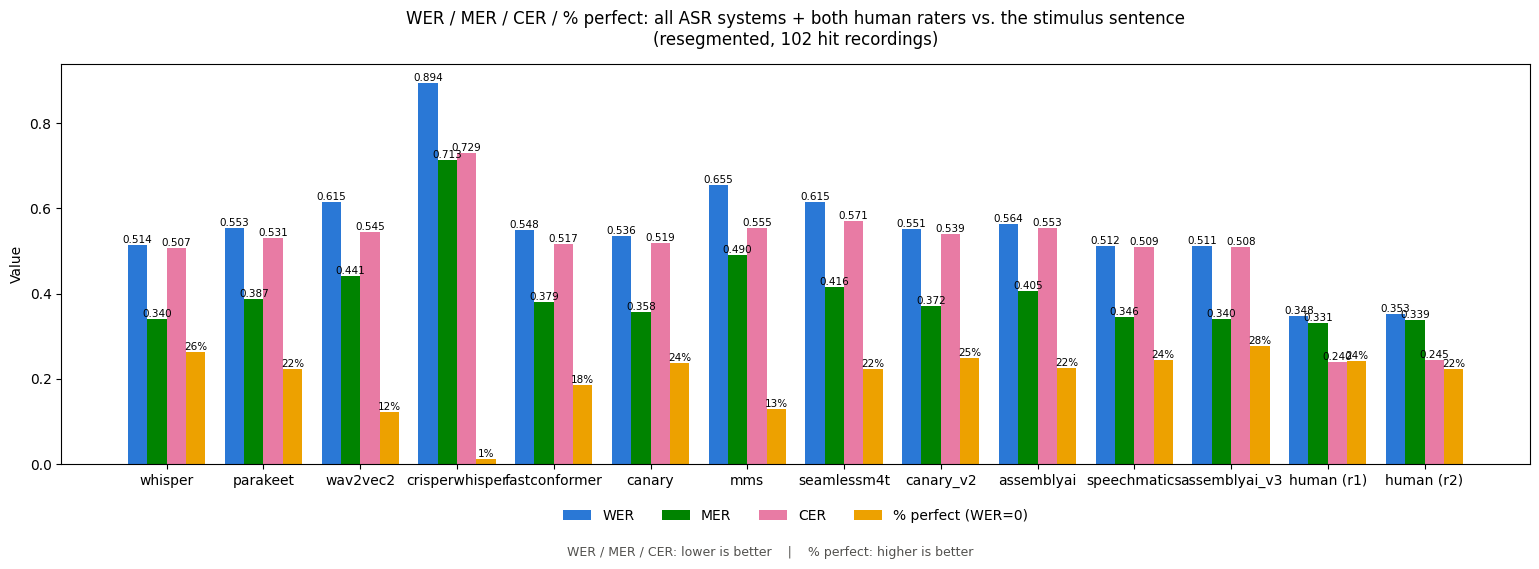

In [14]:
plot_full_summary(
    stimulus_summary_display,
    "WER / MER / CER / % perfect: all ASR systems + both human raters vs. the stimulus sentence\n(resegmented, 102 hit recordings)",
    "../plots/resegmented_vs_stimulus_metrics.png",
    figsize=(15.5, 5.5),
)


**Reading this chart:**

- **The human floor jumps from ~0.16 (vs. the other rater) to ~0.35 (vs. the stimulus)** — rater 1
  0.348, rater 2 0.353. That ~0.19 gap is purely **learner deviation from the scripted sentence**,
  not transcription disagreement — even a transcription both raters would agree on is, on average,
  about a third different (by word) from what the sentence prompt actually said.
- **Every ASR system sits above that ~0.35 human floor**, same qualitative picture as the
  human-transcript comparison. Unlike the earlier (pre-commercial-API) version of this chart, the
  *leaders* here are consistent with the human-floor ranking: **`assemblyai_v3` (0.511) and
  `speechmatics` (0.513) are again the two best systems**, matching their lead against the human
  raters (see the earlier section) rather than reshuffling under this different scoring target.
- **`whisper` (0.514) still narrowly edges `canary` (0.536) here**, the same reversal documented in
  earlier versions of this notebook (canary very slightly leads whisper against the human raters,
  but trails it against the stimulus) — a plausible, if indirect, sighting of the fluency-correction
  behavior discussed in [§4.1 of the analysis doc](../../docs/asr_model_comparison_analysis.md#41-does-an-attention-decoder-inherently-correct-disfluent-speech):
  whisper's language-model prior nudges its output toward the kind of fluent, grammatical phrasing
  the stimulus *is*. That pattern is now a secondary-tier observation, though, since two other
  systems (`assemblyai_v3`, `speechmatics`) beat both of them here regardless.
- **`assemblyai` (Universal-2, unprompted) is unremarkable against the stimulus too** (0.564),
  consistent with its unremarkable showing against the human raters (§3.10 of the analysis doc) —
  the plain API call doesn't distinguish itself on either scoring target; only the prompted
  `assemblyai_v3` configuration does.
- **`crisperwhisper` is still the clear outlier (0.894)** — even worse relative to the stimulus than
  it was relative to human transcriptions (0.690), consistent with §4.4's conclusion that its
  verbatim training objective pulls it away from both ground truths, not just the human-rater one.


## Takeaways

- **`speechmatics` and `assemblyai_v3` are now the two strongest systems overall**, both beating the
  long-standing `canary`/`whisper` tie that held the top spot through the first nine models in this
  comparison — `speechmatics` on WER/MER (0.223/0.207), `assemblyai_v3` on CER and exact-match rate
  (0.130 / 37.0%, the best of any of the twelve systems). See
  `docs/asr_model_comparison_analysis.md` §1.2 for the full writeup and §4.6 for why prompting
  (rather than architecture or training breadth) is the lever that got `assemblyai_v3` there.
- **`assemblyai_v3` is a large improvement over its own predecessor, `assemblyai` (Universal-2)** —
  WER 0.236 vs. 0.290, MER 0.212 vs. 0.279, CER 0.130 vs. 0.187, exact-match 37.0% vs. 35.0%, every
  metric better. The only change between the two runs was the model version (Universal-2 →
  Universal-3.5 Pro) and adding an explicit disfluency-preserving prompt — see
  `notebooks/model_comparison/analyze_assemblyai_v3_transcription_quality.ipynb` for the dedicated writeup.
- **`assemblyai` (Universal-2, unprompted) does not distinguish itself** — despite being the actual
  `autoeit.org` production backend, it lands in the same tier as `parakeet` (WER 0.290 vs. 0.281),
  behind `whisper`/`canary`/`fastconformer` on every error-rate metric. The advisor's qualitative
  production preference for AssemblyAI over Whisper doesn't carry over to a measured accuracy win
  here — see `notebooks/model_comparison/analyze_assemblyai_transcription_quality.ipynb`.
- **`canary` (v1) and `whisper` remain essentially tied for 3rd/4th** (WER 0.248 vs. 0.248, canary
  narrowly ahead on MER and word-perfect rate), with **`fastconformer`** close behind (0.251) —
  unchanged from earlier versions of this comparison.
- **`canary_v2`** (nvidia/canary-1b-v2, a 2026-06-23 follow-up checkpoint to canary-1b) surprisingly
  regresses relative to v1 -- WER 0.301 vs. 0.248 -- despite fixing v1's missing word-level
  timestamps. See `notebooks/model_comparison/analyze_canary_v2_transcription_quality.ipynb` for the full
  head-to-head: v1 wins on 1,672 items where the two disagree, v2 only 766. The likely cause is the
  same one seen with mms vs. wav2vec2 below -- v2's jump from 4 to 25 supported languages appears
  to dilute per-language capacity on this narrow, L2-accented Spanish task.
- `parakeet` and `wav2vec2` remain clearly behind the top tier.
- **`mms` and `seamlessm4t`** (hit-recordings only) land in a lower tier below wav2vec2: seamlessm4t at
  WER 0.377 / CER 0.219, mms at WER 0.399 / CER 0.189. Both underperform their closest
  architectural cousin -- mms loses to wav2vec2 (both CTC, WER 0.399 vs. 0.323) despite ~1,100
  languages of adapter training vs. wav2vec2's dedicated Spanish fine-tune, and seamlessm4t loses to
  whisper/canary (all attention-based, WER 0.377 vs. 0.248) likely because its speech-to-text-
  *translation* objective doesn't transfer cleanly to verbatim transcription -- see the dedicated
  notebooks for the qualitative failure-mode breakdown (mms garbles phonetically, seamlessm4t
  occasionally hallucinates whole unrelated sentences).
- **`crisperwhisper`** remains the clear outlier (WER 0.690) at the bottom of every ranking --
  verbatim-transcription fidelity via *fine-tuning* has not translated into better agreement with
  these raters, in sharp contrast to `assemblyai_v3`'s *prompting*-based approach to the same goal
  (see `docs/asr_model_comparison_analysis.md` §4.6).
- All twelve systems remain above the human floor (WER 0.161), though the gap has narrowed with this
  session's additions -- the best system (`speechmatics`, 0.223) is now ~1.4x the floor, down from
  ~1.5x when `canary`/`whisper` (0.248) were the best available. **`speechmatics` and `assemblyai_v3`
  are the strongest candidates for a pipeline swap from `whisper`** on accuracy grounds, though both
  are paid commercial APIs rather than a free drop-in swap -- see `docs/asr_model_comparison_analysis.md`
  §5 for the full recommendations.
